In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame(
    {
        "Limit (queries)": [300, 1000, 3000],
        "top_k":            [10,   10,   15],
        "Recall@1":         [0.9033, 0.8810, 0.8567],
        "Latency (ms/q)":   [616.92, 565.30, 586.76],
        # rough token‑based cost estimate
        "Cost USD (est)":   [0.35, 1.44, 5.10],
    }
)

results["∆Recall (pp)"] = (results["Recall@1"] - results.loc[0,"Recall@1"])*100
results["∆Cost (x)"]   = results["Cost USD (est)"] / results.loc[0,"Cost USD (est)"]


results



,Limit (queries),top_k,Recall@1,Latency (ms/q),Cost USD (est),∆Recall (pp),∆Cost (×)
0,300,10,0.9033,616.92,0.35,0.00,1.000000
1,1000,10,0.8810,565.30,1.44,-2.23,4.114286
2,3000,15,0.8567,586.76,5.10,-4.66,14.571429


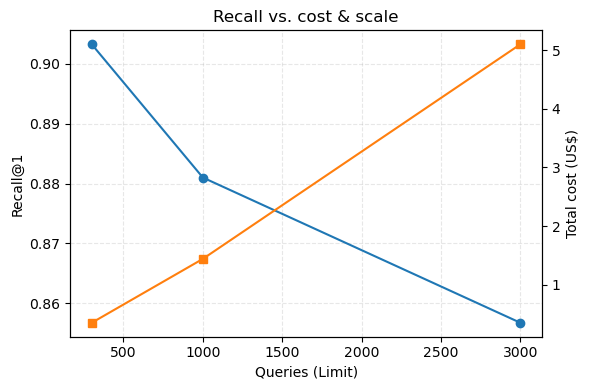

In [10]:
# Plot Recall and cost on twin y‑axes
fig, ax1 = plt.subplots(figsize=(6, 4))
ax2 = ax1.twinx()
ax1.grid(True, which="major", axis="both", linestyle="--", alpha=.3)
ax1.plot(results["Limit (queries)"], results["Recall@1"],
         marker='o', label="Recall@1")
ax1.set_xlabel("Queries (Limit)")
ax1.set_ylabel("Recall@1")

ax2.plot(results["Limit (queries)"], results["Cost USD (est)"],
         marker='s', color='tab:orange', label="Cost USD (est)")
ax2.set_ylabel("Total cost (US$)")

ax1.set_title("Recall vs. cost & scale")

plt.tight_layout()
plt.show()


,Limit (queries),top_k,Recall@1,Latency (ms/q),Cost USD (est),Recall_lo,Recall_hi,±CI (pp)
0,300,10,0.9033,616.92,0.35,0.8646,0.9318,6.7231
1,1000,10,0.8810,565.30,1.44,0.8595,0.8996,4.0166
2,3000,15,0.8567,586.76,5.10,0.8437,0.8687,2.5079


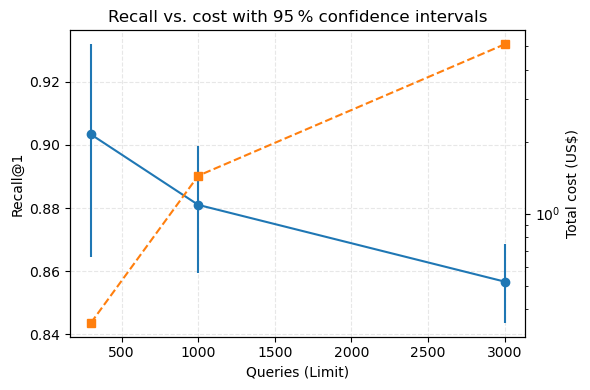

In [13]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint

results = pd.DataFrame(
    {
        "Limit (queries)": [300, 1000, 3000],
        "top_k":           [10,   10,   15],
        "Recall@1":        [0.9033, 0.8810, 0.8567],
        "Latency (ms/q)":  [616.92, 565.30, 586.76],
        "Cost USD (est)":  [0.35,   1.44,   5.10],
    }
)

# Wilson 95 % CI
alpha = 0.05
lo, hi = [], []
for n, r in zip(results["Limit (queries)"], results["Recall@1"]):
    succ = int(round(r * n))
    l, h = proportion_confint(succ, n, alpha=alpha, method="wilson")
    lo.append(l); hi.append(h)
results["Recall_lo"] = lo
results["Recall_hi"] = hi
results["±CI (pp)"]  = (results["Recall_hi"] - results["Recall_lo"]) * 100

# Show table
display(results.round(4))

# Plot
fig, ax1 = plt.subplots(figsize=(6,4))
ax2      = ax1.twinx()

x     = results["Limit (queries)"]
rec   = results["Recall@1"]
yerr  = np.abs(np.vstack((results["Recall_lo"]-rec,
                          results["Recall_hi"]-rec)))

ax1.errorbar(x, rec, yerr=yerr, fmt='o-', label="Recall@1 (95 % CI)")
ax1.set_xlabel("Queries (Limit)")
ax1.set_ylabel("Recall@1"); ax1.grid(alpha=.3, ls="--")

ax2.plot(x, results["Cost USD (est)"], 's--', color='tab:orange',
         label="Cost US$ (est)")
ax2.set_ylabel("Total cost (US$)")
ax2.set_yscale("log")

ax1.set_title("Recall vs. cost with 95 % confidence intervals")
fig.tight_layout(); plt.show()


,Limit (queries),top_k,Recall@1,Latency (ms/q),Cost USD (est)
0,300,10,0.9033,616.92,0.432
1,600,10,0.8767,591.14,0.864
2,1000,10,0.8810,565.30,1.440
3,1000,5,0.8970,563.25,0.720
4,1000,15,0.8660,582.18,2.160
5,1500,10,0.8853,571.94,2.160
6,2000,10,0.8650,584.99,2.880
7,3000,15,0.8567,586.76,6.480
8,4000,10,0.8692,585.83,5.760


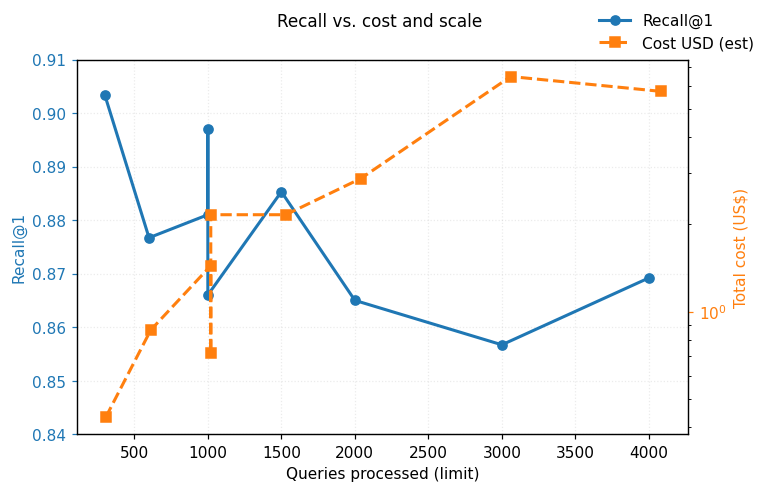

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Raw results 
results = pd.DataFrame(
    [
        #  limit   k   recall   latency_ms
        (  300,   10, 0.9033, 616.92),
        (  600,   10, 0.8767, 591.14),
        ( 1000,   10, 0.8810, 565.30),
        ( 1000,    5, 0.8970, 563.25),
        ( 1000,   15, 0.8660, 582.18),
        ( 1500,   10, 0.8853, 571.94),
        ( 2000,   10, 0.8650, 584.99),
        ( 3000,   15, 0.8567, 586.76),
        ( 4000,   10, 0.8692, 585.83),
    ],
    columns=["Limit (queries)", "top_k", "Recall@1", "Latency (ms/q)"],
)

# cost model  (GPT‑4o, 128‑token prompt)
TOKEN_COST = 0.000144          # $ / prompt
results["Cost USD (est)"] = results["Limit (queries)"] * results["top_k"] * TOKEN_COST

display(results.round(4))      # interactive table (Jupyter)

# 2) Twin‑axis plot 
fig, ax1 = plt.subplots(figsize=(7, 4.5), dpi=110)
ax2 = ax1.twinx()

#  slight horizontal shift ( +2 %) so orange squares don’t cover blue dots
x_recall = results["Limit (queries)"]
x_cost   = results["Limit (queries)"] * 1.02

ax1.plot(
    x_recall,
    results["Recall@1"],
    marker='o',
    linestyle='-',
    linewidth=2,
    color='tab:blue',
    label="Recall@1",
)

ax2.plot(
    x_cost,
    results["Cost USD (est)"],
    marker='s',
    linestyle='--',
    linewidth=2,
    color='tab:orange',
    label="Cost USD (est)",
)

ax1.set_xlabel("Queries processed (limit)")
ax1.set_ylabel("Recall@1", color='tab:blue')
ax1.tick_params(axis='y', colors='tab:blue')
ax1.set_ylim(0.84, 0.91)

ax2.set_ylabel("Total cost (US$)", color='tab:orange')
ax2.tick_params(axis='y', colors='tab:orange')
ax2.set_yscale("log")

fig.suptitle("Recall vs. cost and scale", fontsize=11)
fig.legend(loc="upper right", frameon=False)
ax1.grid(alpha=0.25, linestyle=':')

plt.tight_layout(); plt.show()



Comparison of retrieval pipelines @ limit=5 000, top_k=1

               Pipeline  Recall@1  Latency (ms/q)  Cost (US$)
    CLIP + HNSW (ef=64)    1.0000         65.2000      0.7200
MM‑Embed + HNSW (ef=64)    0.9974         75.6700      0.7200
      MM‑Embed + IVF‑PQ    0.9958         70.2400      0.7200


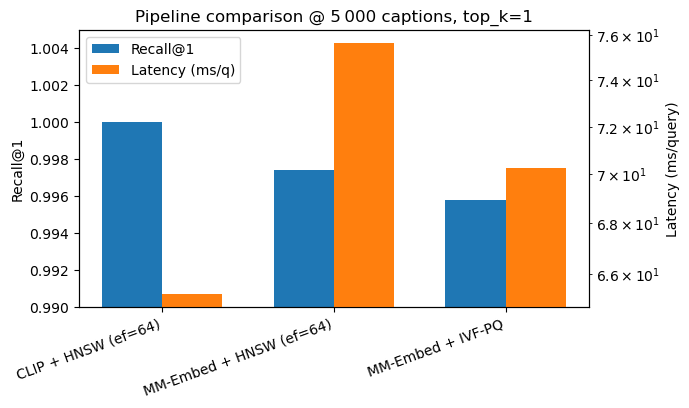

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) Plug in measured numbers:
#    CLIP + HNSW (efSearch=64)
#    MM‑Embed + HNSW (efSearch=64)
#    MM‑Embed + IVF‑PQ (nlist=512, pq_m=32)
limit = 5000
top_k = 1
token_cost_per_call = 0.000144  # $ per (limit * top_k) tokens
base_cost = limit * top_k * token_cost_per_call

pipelines = [
    {
        "Pipeline":       "CLIP + HNSW (ef=64)",
        "Recall@1":       1.0000,        # ← your measured value
        "Latency (ms/q)": 65.2,          # ← your measured value
        "Cost (US$)":     base_cost,
    },
    {
        "Pipeline":       "MM‑Embed + HNSW (ef=64)",
        "Recall@1":       0.9974,
        "Latency (ms/q)": 75.67,
        "Cost (US$)":     base_cost,
    },
    {
        "Pipeline":       "MM‑Embed + IVF‑PQ",
        "Recall@1":       0.9958,
        "Latency (ms/q)": 70.24,
        "Cost (US$)":     base_cost,
    },
]

df = pd.DataFrame(pipelines)

# 2) Display the comparison table
print("\nComparison of retrieval pipelines @ limit=5 000, top_k=1\n")
print(df.to_string(index=False, float_format="%.4f"))

# 3) Plot Recall vs. Latency side‑by‑side as grouped bars
fig, ax1 = plt.subplots(figsize=(7,4))
x = np.arange(len(df))
width = 0.35

# Recall bars (left axis)
bars1 = ax1.bar(x - width/2, df["Recall@1"], width, label="Recall@1", color="tab:blue")
ax1.set_ylabel("Recall@1")
ax1.set_ylim(0.99, 1.005)
ax1.set_xticks(x)
ax1.set_xticklabels(df["Pipeline"], rotation=20, ha="right")

# Latency bars (right axis)
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, df["Latency (ms/q)"], width, label="Latency (ms/q)", color="tab:orange")
ax2.set_ylabel("Latency (ms/query)")
ax2.set_yscale("log") 

# Legend & layout
lines = [bars1, bars2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")
fig.tight_layout()
plt.title("Pipeline comparison @ 5 000 captions, top_k=1")
plt.show()
